In [2]:
import torch

In [4]:
torch.cuda.is_available()

True

In [5]:
print(torch.__version__)

2.6.0+cu124


In [13]:
import csv
import json
from collections import Counter
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

from weed_detection import logger
import os
import pandas as pd

In [16]:
csv_path = '../artifacts/data_ingestion/unzipped/v_20260307_192121_5a0b6671da93a189'

csv_file = os.path.join(csv_path,'labels','labels.csv')
df = pd.read_csv(csv_file,sep=",")
df.head()


,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


In [31]:
NUM_CLASSES = len(df['Label'].unique())

number of output classes is 9

In [19]:
image_name = df['Filename']
image_name

0        20160928-140314-0.jpg
1        20160928-140337-0.jpg
2        20160928-140731-0.jpg
3        20160928-140747-0.jpg
4        20160928-141107-0.jpg
                 ...          
17504    20180322-133822-1.jpg
17505    20180322-133832-1.jpg
17506    20180322-133840-1.jpg
17507    20180322-133850-1.jpg
17508    20180322-133901-1.jpg
Name: Filename, Length: 17509, dtype: object

In [21]:
images_dir = os.path.join(csv_path, 'images')
os.path.exists(images_dir)

True

In [22]:
first_image_path = os.path.join(images_dir, image_name.iloc[0])

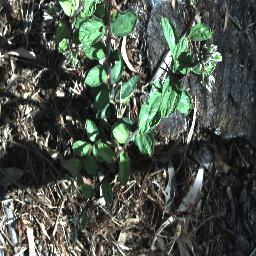

In [30]:
Image.open(first_image_path).convert("RGB")

In [32]:

if 'Species' in df.columns:
    # Create mapping from unique pairs
    unique_pairs = df[['Label', 'Species']].drop_duplicates().sort_values('Label')
    SPECIES_MAP = dict(zip(unique_pairs['Label'], unique_pairs['Species']))

print("=" * 60)
print("🗺️ SPECIES MAPPING")
print("=" * 60)
for label, species in sorted(SPECIES_MAP.items()):
    print(f"   Label {label}: {species}")

🗺️ SPECIES MAPPING
   Label 0: Chinee apple
   Label 1: Lantana
   Label 2: Parkinsonia
   Label 3: Parthenium
   Label 4: Prickly acacia
   Label 5: Rubber vine
   Label 6: Siam weed
   Label 7: Snake weed
   Label 8: Negative


In [33]:
print("=" * 60)
print("📊 CLASS DISTRIBUTION ANALYSIS")
print("=" * 60)

# Get class counts
class_counts = df['Label'].value_counts().sort_index()
total_samples = len(df)

print(f"\n📈 Total samples: {total_samples}")
print(f"\n📊 Per-class distribution:")
print("-" * 60)
print(f"{'Label':<6} {'Species':<20} {'Count':<10} {'Percentage':<10}")
print("-" * 60)

for label in sorted(SPECIES_MAP.keys()):
    count = class_counts.get(label, 0)
    percentage = (count / total_samples) * 100
    species = SPECIES_MAP.get(label, f"Unknown_{label}")
    print(f"{label:<6} {species:<20} {count:<10} {percentage:.2f}%")

# Calculate imbalance metrics
print("\n📉 IMBALANCE METRICS:")
print("-" * 60)
print(f"   Most frequent class: Label {class_counts.idxmax()} ({class_counts.max()} samples)")
print(f"   Least frequent class: Label {class_counts.idxmin()} ({class_counts.min()} samples)")
print(f"   Ratio (max/min): {class_counts.max() / class_counts.min():.2f}:1")
print(f"   Standard deviation: {class_counts.std():.2f}")
print(f"   Coefficient of variation: {(class_counts.std() / class_counts.mean()):.2f}")

📊 CLASS DISTRIBUTION ANALYSIS

📈 Total samples: 17509

📊 Per-class distribution:
------------------------------------------------------------
Label  Species              Count      Percentage
------------------------------------------------------------
0      Chinee apple         1125       6.43%
1      Lantana              1064       6.08%
2      Parkinsonia          1031       5.89%
3      Parthenium           1022       5.84%
4      Prickly acacia       1062       6.07%
5      Rubber vine          1009       5.76%
6      Siam weed            1074       6.13%
7      Snake weed           1016       5.80%
8      Negative             9106       52.01%

📉 IMBALANCE METRICS:
------------------------------------------------------------
   Most frequent class: Label 8 (9106 samples)
   Least frequent class: Label 5 (1009 samples)
   Ratio (max/min): 9.02:1
   Standard deviation: 2685.45
   Coefficient of variation: 1.38


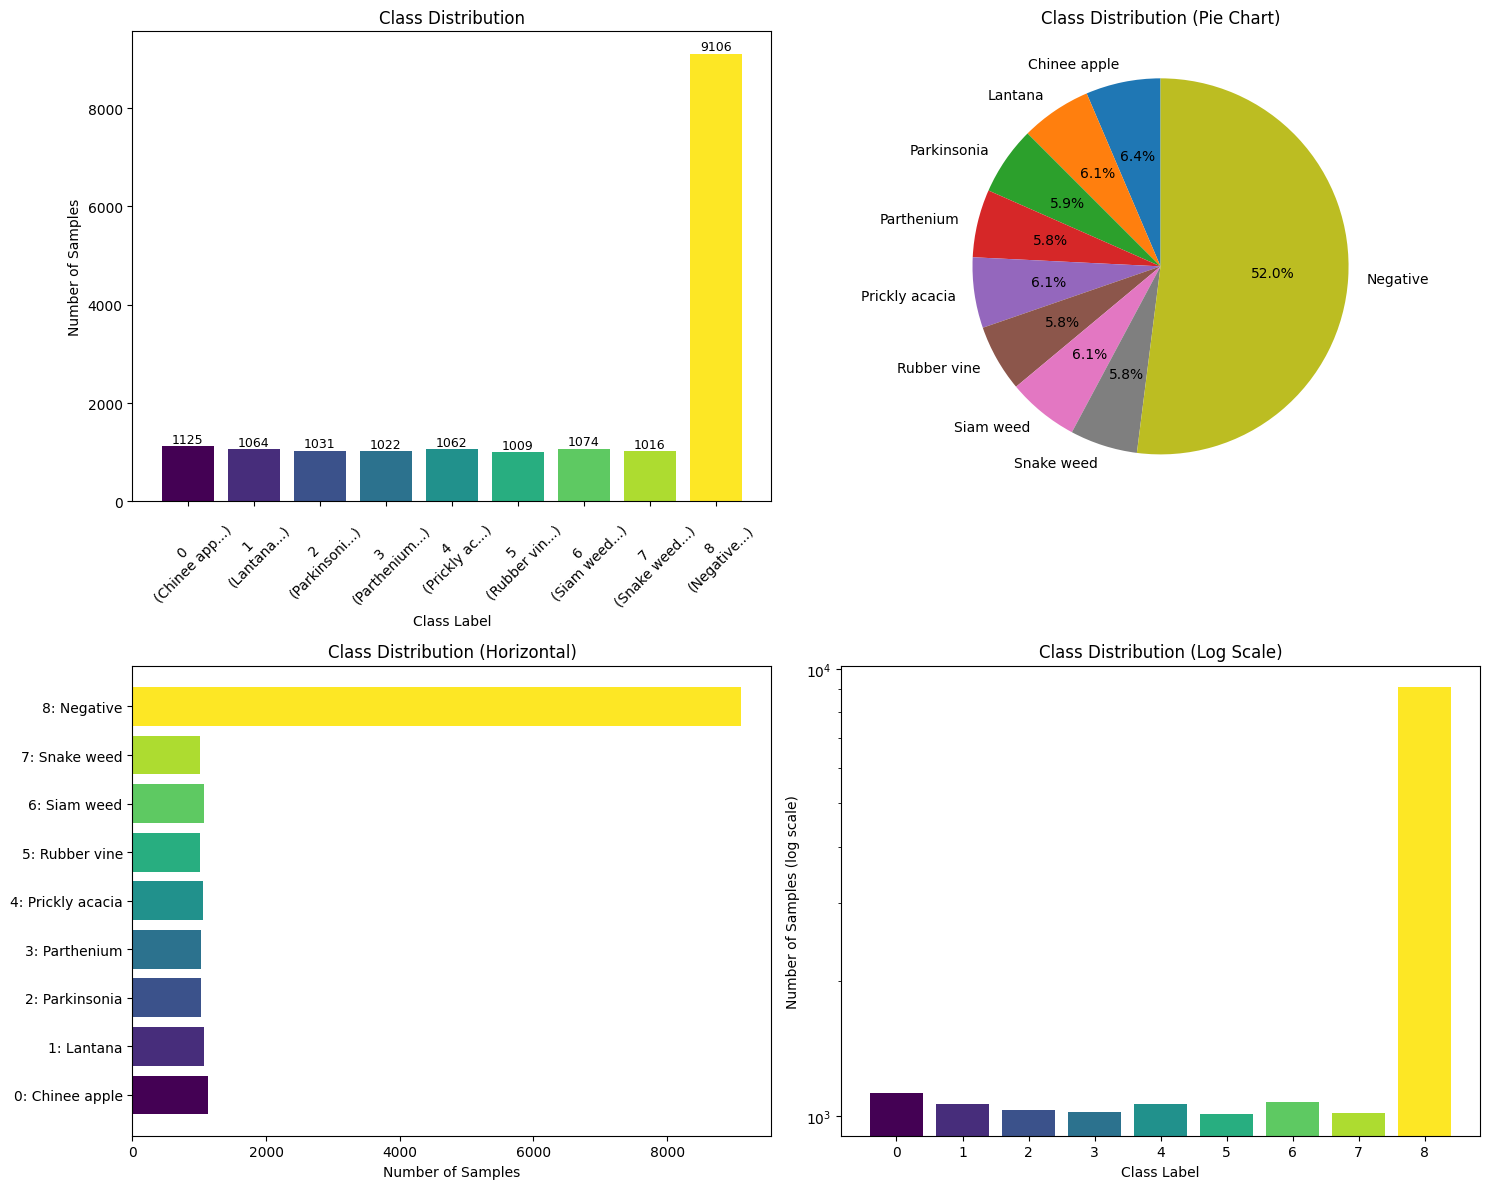

In [36]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Bar plot of class distribution
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(class_counts)))
bars = ax1.bar(range(len(class_counts)), class_counts.values, color=colors)
ax1.set_xlabel('Class Label')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Class Distribution')
ax1.set_xticks(range(len(class_counts)))
ax1.set_xticklabels([f'{i}\n({SPECIES_MAP[i][:10]}...)' for i in class_counts.index], rotation=45)

# Add value labels on bars
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', va='bottom', fontsize=9)

# Plot 2: Pie chart
ax2 = axes[0, 1]
labels = [f'{SPECIES_MAP[i][:15]}...' if len(SPECIES_MAP[i]) > 15 else SPECIES_MAP[i] 
          for i in class_counts.index]
ax2.pie(class_counts.values, labels=labels, autopct='%1.1f%%', startangle=90)
ax2.set_title('Class Distribution (Pie Chart)')

# Plot 3: Horizontal bar chart
ax3 = axes[1, 0]
y_pos = np.arange(len(class_counts))
ax3.barh(y_pos, class_counts.values, color=colors)
ax3.set_yticks(y_pos)
ax3.set_yticklabels([f'{i}: {SPECIES_MAP[i]}' for i in class_counts.index])
ax3.set_xlabel('Number of Samples')
ax3.set_title('Class Distribution (Horizontal)')

# Plot 4: Log scale distribution
ax4 = axes[1, 1]
ax4.bar(range(len(class_counts)), class_counts.values, color=colors, log=True)
ax4.set_xlabel('Class Label')
ax4.set_ylabel('Number of Samples (log scale)')
ax4.set_title('Class Distribution (Log Scale)')
ax4.set_xticks(range(len(class_counts)))
ax4.set_xticklabels(class_counts.index)

plt.tight_layout()
plt.show()

In [37]:
print("=" * 60)
print("⚖️ CLASS WEIGHT CALCULATION")
print("=" * 60)

def compute_class_weights(counts: pd.Series, total_samples: int, num_classes: int) -> dict:
    """
    Calculate inverse frequency weights for each class.
    
    Formula: weight[i] = total_samples / (num_classes * count[i])
    
    Args:
        counts: Series with class counts
        total_samples: Total number of samples
        num_classes: Number of classes
    
    Returns:
        Dictionary with class weights
    """
    weights = {}
    
    print("\n📊 Weight Calculation:")
    print("-" * 70)
    print(f"{'Class':<6} {'Species':<20} {'Count':<10} {'Weight':<12} {'Formula':<20}")
    print("-" * 70)
    
    for label in range(num_classes):
        count = counts.get(label, 0)
        
        if count > 0:
            weight = total_samples / (num_classes * count)
            formula = f"{total_samples}/({num_classes}×{count})"
        else:
            weight = 0.0
            formula = "N/A (zero samples)"
        
        weights[label] = round(weight, 6)
        species = SPECIES_MAP.get(label, f"Unknown_{label}")
        
        print(f"{label:<6} {species:<20} {count:<10} {weights[label]:<12.4f} {formula}")
    
    print("-" * 70)
    return weights

# Calculate weights
class_weights = compute_class_weights(class_counts, total_samples, NUM_CLASSES)

print("\n📈 Weight Statistics:")
print(f"   Min weight: {min(class_weights.values()):.4f}")
print(f"   Max weight: {max(class_weights.values()):.4f}")
print(f"   Mean weight: {np.mean(list(class_weights.values())):.4f}")
print(f"   Sum of weights: {np.sum(list(class_weights.values())):.4f}")

⚖️ CLASS WEIGHT CALCULATION

📊 Weight Calculation:
----------------------------------------------------------------------
Class  Species              Count      Weight       Formula             
----------------------------------------------------------------------
0      Chinee apple         1125       1.7293       17509/(9×1125)
1      Lantana              1064       1.8284       17509/(9×1064)
2      Parkinsonia          1031       1.8869       17509/(9×1031)
3      Parthenium           1022       1.9036       17509/(9×1022)
4      Prickly acacia       1062       1.8319       17509/(9×1062)
5      Rubber vine          1009       1.9281       17509/(9×1009)
6      Siam weed            1074       1.8114       17509/(9×1074)
7      Snake weed           1016       1.9148       17509/(9×1016)
8      Negative             9106       0.2136       17509/(9×9106)
----------------------------------------------------------------------

📈 Weight Statistics:
   Min weight: 0.2136
   Max weight: 1

In [39]:
inverse_weights = {}
print("\n⚖️ Calculating inverse class weights:")
print("-" * 60)
print(f"{'Class':<6} {'Count':<10} {'Weight':<12}")
print("-" * 60)

for label in range(NUM_CLASSES):
    count = class_counts.get(label, 0)
    if count > 0:
        weight = total_samples / (NUM_CLASSES * count)
    else:
        weight = 0.0
    inverse_weights[label] = round(weight, 6)
    print(f"{label:<6} {count:<10} {inverse_weights[label]:<12.4f}")


⚖️ Calculating inverse class weights:
------------------------------------------------------------
Class  Count      Weight      
------------------------------------------------------------
0      1125       1.7293      
1      1064       1.8284      
2      1031       1.8869      
3      1022       1.9036      
4      1062       1.8319      
5      1009       1.9281      
6      1074       1.8114      
7      1016       1.9148      
8      9106       0.2136      


🎲 WEIGHTED RANDOM SAMPLER PREPARATION

📋 Creating sample weights:
------------------------------------------------------------
   Total samples: 17509
   Min sample weight: 0.2136
   Max sample weight: 1.9281
   Mean sample weight: 1.0000
   Std sample weight: 0.8198


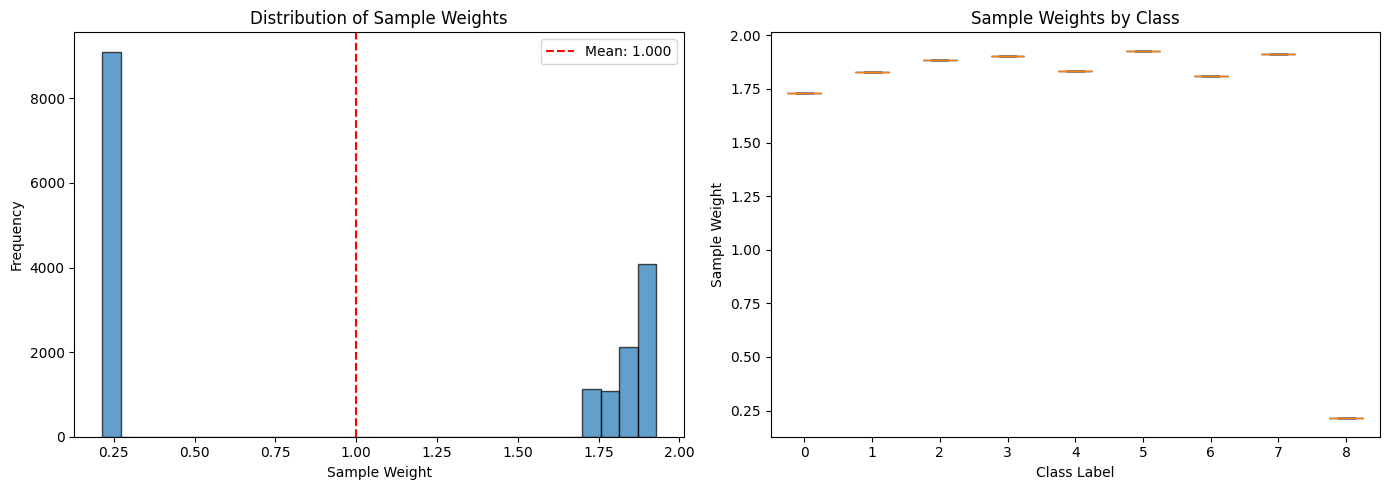

In [40]:
print("=" * 60)
print("🎲 WEIGHTED RANDOM SAMPLER PREPARATION")
print("=" * 60)

# Create sample weights for each individual sample
def create_sample_weights(df: pd.DataFrame, class_weights: dict) -> np.ndarray:
    """
    Create weights for each sample based on its class
    
    Args:
        df: DataFrame with 'Label' column
        class_weights: Dictionary mapping class to weight
    
    Returns:
        Array of weights for each sample
    """
    sample_weights = []
    
    print("\n📋 Creating sample weights:")
    print("-" * 60)
    
    for label in df['Label']:
        weight = class_weights[label]
        sample_weights.append(weight)
    
    sample_weights = np.array(sample_weights)
    
    print(f"   Total samples: {len(sample_weights)}")
    print(f"   Min sample weight: {sample_weights.min():.4f}")
    print(f"   Max sample weight: {sample_weights.max():.4f}")
    print(f"   Mean sample weight: {sample_weights.mean():.4f}")
    print(f"   Std sample weight: {sample_weights.std():.4f}")
    
    return sample_weights

# Create sample weights
sample_weights = create_sample_weights(df, inverse_weights)

# Visualize sample weight distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of sample weights
ax1.hist(sample_weights, bins=30, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Sample Weight')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Sample Weights')
ax1.axvline(sample_weights.mean(), color='red', linestyle='--', 
            label=f'Mean: {sample_weights.mean():.3f}')
ax1.legend()

# Plot 2: Box plot by class
class_weight_lists = []
for label in range(NUM_CLASSES):
    mask = df['Label'] == label
    class_weight_lists.append(sample_weights[mask])

bp = ax2.boxplot(class_weight_lists, patch_artist=True)
ax2.set_xlabel('Class Label')
ax2.set_ylabel('Sample Weight')
ax2.set_title('Sample Weights by Class')
ax2.set_xticklabels([f'{i}' for i in range(NUM_CLASSES)])

# Color boxes
colors = plt.cm.viridis(np.linspace(0, 1, NUM_CLASSES))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.tight_layout()
plt.show()

In [41]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
NUM_CLASSES = 9
input_size = 224

In [42]:
print("\n📋 STEP 1: Defining Transformations")
print("-" * 60)

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
    ),
    transforms.RandomResizedCrop(
        size=input_size,
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1),
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation/Test transforms (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("✅ Training transforms (with augmentation):")
for i, t in enumerate(train_transform.transforms, 1):
    print(f"   {i}. {type(t).__name__}")

print("\n✅ Validation transforms (no augmentation):")
for i, t in enumerate(eval_transform.transforms, 1):
    print(f"   {i}. {type(t).__name__}")


📋 STEP 1: Defining Transformations
------------------------------------------------------------
✅ Training transforms (with augmentation):
   1. Resize
   2. RandomHorizontalFlip
   3. RandomVerticalFlip
   4. RandomRotation
   5. ColorJitter
   6. RandomResizedCrop
   7. ToTensor
   8. Normalize

✅ Validation transforms (no augmentation):
   1. Resize
   2. CenterCrop
   3. ToTensor
   4. Normalize


In [44]:
import random
sample_images = []
sample_labels = []
classes_to_sample = min(3, NUM_CLASSES)  # Sample from up to 3 classes

for class_id in range(classes_to_sample):
    class_images = df[df['Label'] == class_id]['Filename'].tolist()
    if class_images:
        # Take up to 2 images per class
        num_to_take = min(2, len(class_images))
        selected = random.sample(class_images, num_to_take)
        for img_name in selected:
            img_path = os.path.join(images_dir, img_name)
            if os.path.exists(img_path):
                sample_images.append(img_path)
                sample_labels.append(class_id)
                print(f"✅ Loaded: Class {class_id} ({SPECIES_MAP[class_id]}) - {img_name}")

print(f"\n📸 Total sample images loaded: {len(sample_images)}")

✅ Loaded: Class 0 (Chinee apple) - 20170410-154156-0.jpg
✅ Loaded: Class 0 (Chinee apple) - 20170410-124637-0.jpg
✅ Loaded: Class 1 (Lantana) - 20170715-131423-1.jpg
✅ Loaded: Class 1 (Lantana) - 20170714-145855-1.jpg
✅ Loaded: Class 2 (Parkinsonia) - 20170920-162530-3.jpg
✅ Loaded: Class 2 (Parkinsonia) - 20171102-122911-2.jpg

📸 Total sample images loaded: 6



🔄 STEP 3: Visualizing Individual Transform Steps

📸 Showing transform steps for: 20170410-154156-0.jpg


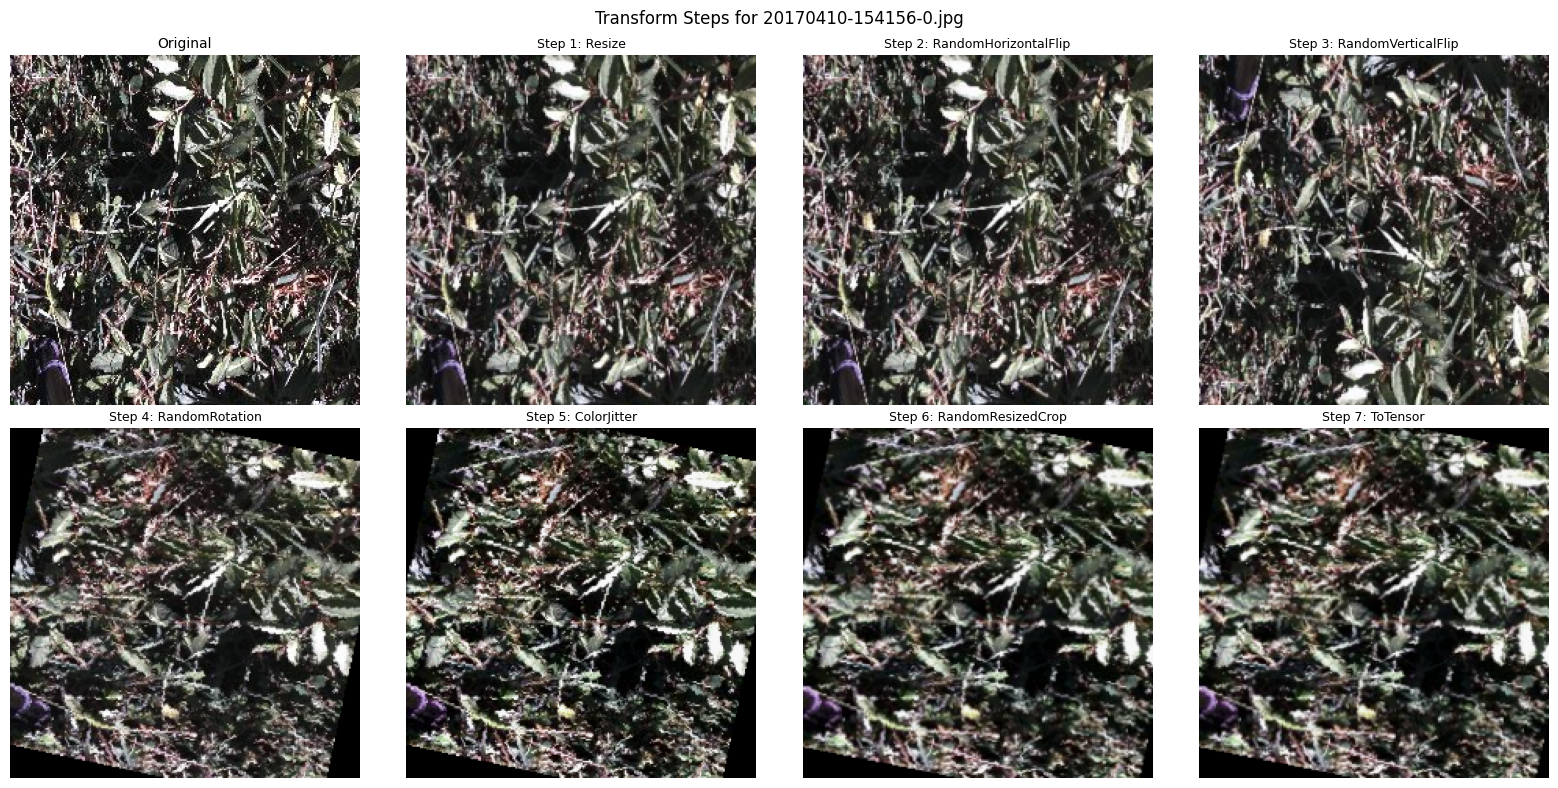

In [45]:
print("\n" + "=" * 60)
print("🔄 STEP 3: Visualizing Individual Transform Steps")
print("=" * 60)

def show_transform_steps(image_path, transform_compose):
    """Show the effect of each transform step"""
    
    # Load original image
    original_img = Image.open(image_path).convert('RGB')
    
    # Create a figure
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # Show original
    axes[0].imshow(original_img)
    axes[0].set_title('Original', fontsize=10)
    axes[0].axis('off')
    
    # Apply transforms step by step
    current_img = original_img.copy()
    
    for i, transform in enumerate(transform_compose.transforms, 1):
        if i >= len(axes):  # Don't exceed number of subplots
            break
            
        try:
            # Apply transform
            if isinstance(transform, transforms.ToTensor):
                # For ToTensor, convert back to PIL for display
                tensor_img = transform(current_img)
                # Denormalize if needed (but we're not normalizing yet)
                display_img = transforms.ToPILImage()(tensor_img)
                axes[i].imshow(display_img)
            elif isinstance(transform, transforms.Normalize):
                # Skip showing Normalize as it changes pixel values dramatically
                continue
            else:
                current_img = transform(current_img)
                axes[i].imshow(current_img)
            
            axes[i].set_title(f'Step {i}: {type(transform).__name__}', fontsize=9)
            axes[i].axis('off')
            
        except Exception as e:
            print(f"   Error at step {i}: {e}")
            axes[i].set_title(f'Step {i}: Error', fontsize=9)
            axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'Transform Steps for {os.path.basename(image_path)}', fontsize=12)
    plt.tight_layout()
    plt.show()

# Show for first sample image
if sample_images:
    print(f"\n📸 Showing transform steps for: {os.path.basename(sample_images[0])}")
    show_transform_steps(sample_images[0], train_transform)